# Проверка гипотезы в Python и составление аналитической записки

## Цели и задачи проекта

**Цель проекта:** Проверить гипотезу, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

Нулевая гипотеза H0: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

Альтернативная гипотеза H1: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

**Задачи**:
1. Выгрузка и ознакомление с данными.
2. Предобработка данных.
3. Применение статистического теста для проверки гипотезы.
4. Подведение итогов исследования в форме аналитической записки.

## Описание данных

Данные представлены в виде одной таблицы, содержащией информацию о времени активности пользователей приложения из Москвы и Санкт-Петербурга. Таблица включает в себя следующие столбцы:
- city - город пользователя (Москва или Санкт-Петербург)
- puid - индификационный номер пользователя
- hours - количество часов, проведённых в приложении, за период исследования.


## Содержимое проекта

1. Загрузка данных и знакомство с ними
2. Проверка гипотезы в Python
3. Аналитическая записка

---

## 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
# Загружаем библиотеки для проведения статистического теста
from scipy.stats import mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest
# Загружаем библиотеки для проверки размера выборки
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

In [2]:
# Выгружаем данные в переменную df (без столбца 'Unnamed: 0')
df = pd.read_csv('https://.../knigi_data.csv', index_col=0)  

In [3]:
# Выводим первые строки датафрейма на экран
df.head() 

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [4]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB


Таблица включает в себя 8784 строки и 3 столбца. Пропуски в таблице отсутствуют, тип данных соответствует ожидаемому.

In [5]:
# Проверяем наличие дубликатов
df.duplicated().sum() 

0

In [6]:
# Проверяем наличие неявных дубликатов
df.duplicated(subset=['puid']).sum() 

244

In [7]:
# Сохраняем id дублирующихся пользователей
puid_duplicated = df[df.duplicated(subset=['puid'])]['puid'].to_list()
df[df['puid'].isin(puid_duplicated)].sort_values(by=['puid', 'hours']).head(10) 

,city,puid,hours
6247,Санкт-Петербург,2637041,3.883926
35,Москва,2637041,10.317371
6274,Санкт-Петербург,9979490,1.302997
134,Москва,9979490,32.415573
6279,Санкт-Петербург,10597984,9.041320
145,Москва,10597984,42.931506
6283,Санкт-Петербург,10815097,0.323291
150,Москва,10815097,9.086655
6300,Санкт-Петербург,13626259,1.648434
187,Москва,13626259,21.104167


In [8]:
# Подсчитываем долю дубликатов
100 * len(puid_duplicated) / df['puid'].nunique() 

2.857142857142857

По итогам проверки дубликатов в данных явное дублирование строк не обнаружено. Однако, было обнаружено наличие неявных дубликатов в поле puid в количестве 244. Подробно изучив эти дубликаты можно заметить, что количество часов и город дублирующихся пользователей отличается. Если предположить, что данные о местоположении пользователя собираются на основе его геолокации, то можно сделать вывод, что наличие таких дубликатов будет естетвенным, например, в случае путешествия или командировки пользователя приложения. 

Доля таких пользователей составляет чуть более 2,85 %, что является немалым результатом. Но так как точно установить, к какому городу относится пользователь, не представляется возможным, данные дубликаты нужно удалить, чтобы избежать искажения результатов исследования.

Отсутствие дубликатов в поле puid будет означать, что пользователи из разных городов не пересекаются, следовательно выборки будут независимы и сопостовимы.

In [9]:
# Удаляем неявные дубликаты в поле puid
df = df.drop_duplicates(subset=['puid'])
print(f"Количество оставшихся дубликатов: {df.duplicated(subset=['puid']).sum()}")

Количество оставшихся дубликатов: 0


In [10]:
# Разделяем пользователей на группы по городам
df_msk = df[df['city'] == 'Москва']
df_spb = df[df['city'] == 'Санкт-Петербург']
display(df_msk.head(), df_spb.head())

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


,city,puid,hours
6234,Санкт-Петербург,104923,60.353889
6235,Санкт-Петербург,146427,0.469559
6236,Санкт-Петербург,295646,1.258954
6237,Санкт-Петербург,601665,0.089076
6238,Санкт-Петербург,639360,0.334019


In [11]:
# Подсчитываем количество пользователей в группах
count_msk_puid = df_msk['puid'].count()
count_spb_puid = df_spb['puid'].count()
difference = count_msk_puid - count_spb_puid
print(f'Размер первой группы (Москва): {count_msk_puid}')
print(f'Размер второй группы (Санкт-Петербург): {count_spb_puid}')
print(f'Разница в группах: {difference}')

Размер первой группы (Москва): 6234
Размер второй группы (Санкт-Петербург): 2306
Разница в группах: 3928


В группах наблюдается разное количество данных: для Москвы - 6234, для Санкт-Петербурга - 2306. Несмотря на большую разницу в размерах выборок, для групп возможно провести t-теста, т.к. количество значений для каждой группы довольно большое. Однако, для проведения t-теста необходимо соответствие данных следующим условиям:
- нормальное распределение значений;
- значения в выборках должны быть независимыми и распределены одинаково;
- дисперсии выборок должны быть равными
- отсутствие экстримальных выбросов.

In [12]:
# Создаём переменные с данными о часах, проведённых в приложении, пользователей двух групп
hours_msk = df_msk['hours']
hours_spb = df_spb['hours']

In [13]:
# Выводим основные статистические показатели по данным группы из Москвы
hours_msk.describe()

count    6234.000000
mean       10.881092
std        36.851683
min         0.000018
25%         0.059903
50%         0.924498
75%         5.939972
max       857.209373
Name: hours, dtype: float64

In [14]:
# Выводим основные статистические показатели по данным группы из Санкт-Петербурга
hours_spb.describe()

count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64

Проанализировав статистические показатели двух групп, можно сделать следующие выводы:
1. Центральная тенденция
- Средние значения очень близки: (10.88 и 11.26)
- Медианы очень близки: (0.92 и 0.88)
- Средние значения сильно превышают медианы, что указывает на сильную правостороннюю асимметрию
2. Разброс данных
- Стандартные отклонения довольно близки (36.85 и 39.83)
- Межквантильные размахи также близки (МСК: 5.94 - 0.06 = 5.88; СПБ: 6.14 - 0.06 = 6.08)
3. Большие максимальные значения могут свидетельствовать о наличии экстримальных выбросов в данных

Таким образом, распределения двух выборок статистически очень похожи, однако, они обладают сильной правосторонней ассиметрией с экстримальными выбросами

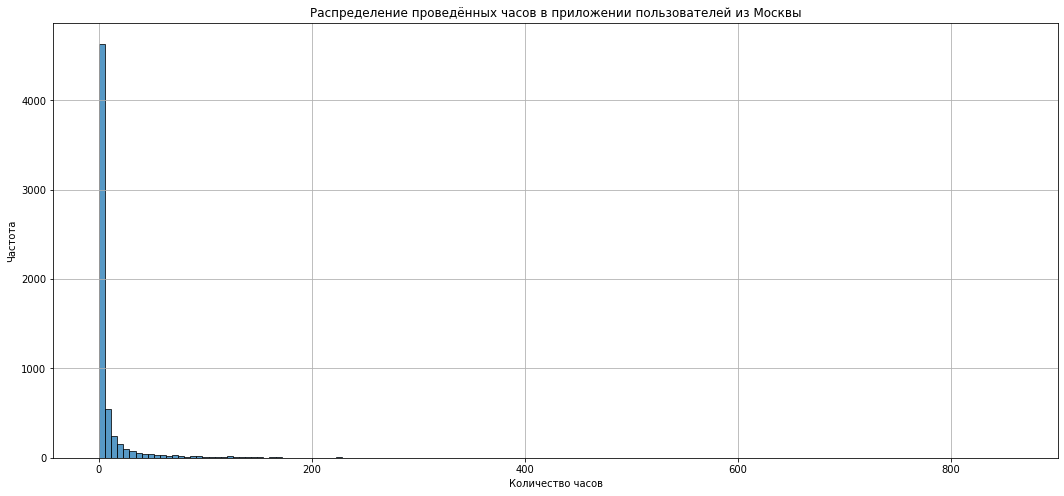

In [15]:
# Строим гистограмму для пользователей из Москвы
plt.figure(figsize=(18, 8))


hours_msk.plot(
            kind='hist',
            bins=150, 
            alpha=0.75,
            edgecolor='black'
)


plt.title('Распределение проведённых часов в приложении пользователей из Москвы')
plt.xlabel('Количество часов')
plt.ylabel('Частота')
plt.grid()
plt.show() 

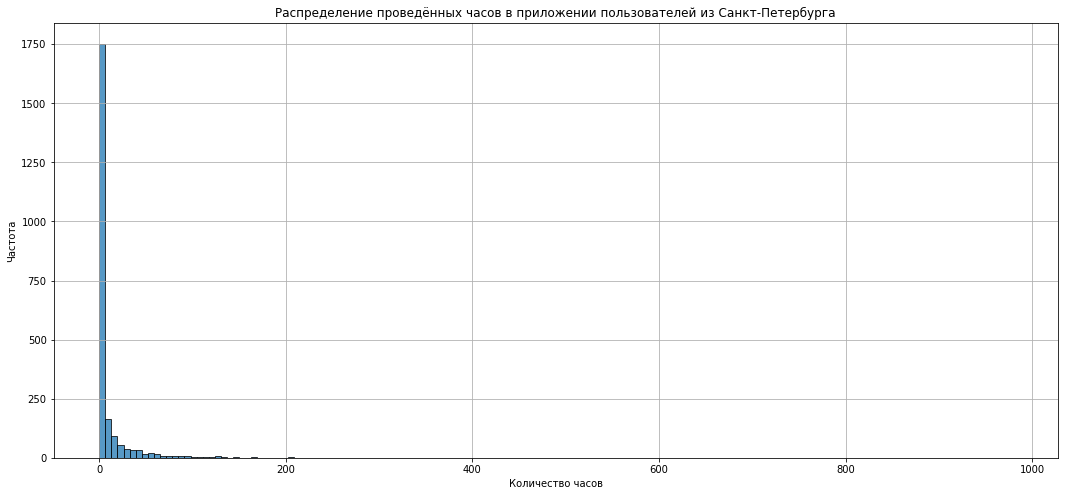

In [16]:
# Строим гистограмму для пользователей из Санкт-Петербурга
plt.figure(figsize=(18, 8))


hours_spb.plot(
            kind='hist',
            bins=150, 
            alpha=0.75,
            edgecolor='black'
)


plt.title('Распределение проведённых часов в приложении пользователей из Санкт-Петербурга')
plt.xlabel('Количество часов')
plt.ylabel('Частота')
plt.grid()
plt.show() 

Графики распределения двух групп подтверждают выводы, сделанные на основе анализа статистических значений. Форма распределения одинаковая как для пользователей из Москвы, так и для пользователей из Санкт-Петербурга. Распределение в группах имеет чётко выраженную правостороннюю ассиметрию с длинным хвостом экстримальных выбросов.

## 2. Проверка гипотезы в Python

**Выбор теста:**

В связи c тем, что графики распределения выборок имеют чётко выраженную правостороннюю асимметрию, применение t-тест может привести к некорректным результатам. В данном случае наиболее наиболее подходящим методом статистического тестирования является непараметрический тест Манна-Уитни по следующим причинам:
- отсутствует требование к нормальности распределения данных;
- устойчивость к выбросам.

In [17]:
# Проверяем гипотизу с помощью статистического теста
alpha = 0.05
mw_test = mannwhitneyu(
    hours_spb,
    hours_msk,
    alternative='greater'
)
if mw_test.pvalue > alpha:
    print(f'pvalue={mw_test.pvalue} > {alpha}')
    print('Нет оснований отвергнуть нулевую гипотезу! Распределения метрики пользователей Москвы и Санкт-Петербурга равны')
else:
    print(f'pvalue={mw_test.pvalue} < {alpha}')
    print('Достаточно оснований, чтобы отвергнуть нулевую гипотезу! Распределения метрики пользователей в Санкт-Петербурге больше, чем в Москве')

pvalue=0.6189600878052618 > 0.05
Нет оснований отвергнуть нулевую гипотезу! Распределения метрики пользователей Москвы и Санкт-Петербурга равны


Проведённый статистический тест показал, что активность пользователей в Москве и Санкт-Петербурге статистически не различается.

## 3. Аналитическая записка

В рамках исследования проводилась проверка гипотезы, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Для проведения анализа были сформированы нулевая и альтернативная гипотеза:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

При изучении статистических показателей и распределения данных было выявлено, что форма распределения значений одинаковая как для пользователей из Москвы, так и для пользователей из Санкт-Петербурга. Однако, распределение в группах имеет чётко выраженную правостороннюю ассиметрию с длинным хвостом экстримальных выбросов. 

В этой связи, в качестве статистического теста, был выбран тест Манна-Уитни, уровень статистической значимости α = 0.05.

Результат теста показал значение p-value: 0.6189600878052618, что во много раз больше уровеня статистической значимости α. Основания отвергнуть нулевую гипотезу отсутствуют, распределение времени пользования приложением у пользователей Москвы и Санкт-Петербурга равное.

Таким образом, нет статистически значимых доказательств того, что пользователи Санкт-Петербурга проводят в приложении больше времени, чем пользователи Москвы. Любые наблюдаемые различия в активностях могут быть объяснены случайной вариацией данных.

Можно предположить, что полученный результат объясняется однородностью в поведении пользователей крупнейших городов России. У пользователей таких городов обычно схожие демографические, социально-экономические и культурные признаки, что оказывает влияние на их потребительское поведение.